In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as cx
import folium
from folium.plugins import HeatMap
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress, spearmanr

In [9]:
dataset_path = "./dataset_earthquake_full.csv"
df = pd.read_csv(dataset_path)
df.head()

,Origin_Time,Latitude,Longitude,Depth,Magnitude,Max_Acc[gal],Max_Vel[cm/s],Seismic_Intensity,Num_Stations
0,2003/01/01 23:18:00,36.430,140.630,55,4.0,27.4,0.4,1.9,18
1,2003/01/01 19:49:00,38.730,141.155,5,3.2,6.5,0.1,0.7,5
2,2003/01/01 07:29:00,44.719,146.289,203,5.1,9.5,0.4,1.8,50
3,2002/12/31 19:11:00,37.066,141.489,47,4.6,11.2,0.3,1.7,52
4,2002/12/30 12:08:00,35.211,139.017,0,3.1,28.4,0.3,1.5,2


Number of earthquakes: 20317

Columns in the dataset: ['Origin_Time', 'Latitude', 'Longitude', 'Depth', 'Magnitude', 'Max_Acc[gal]', 'Max_Vel[cm/s]', 'Seismic_Intensity', 'Num_Stations']

Magnitude statistics:
count    20317.000000
mean         2.118393
std          0.923299
min         -1.800000
25%          1.500000
50%          2.000000
75%          2.600000
max          6.700000
Name: Seismic_Intensity, dtype: float64


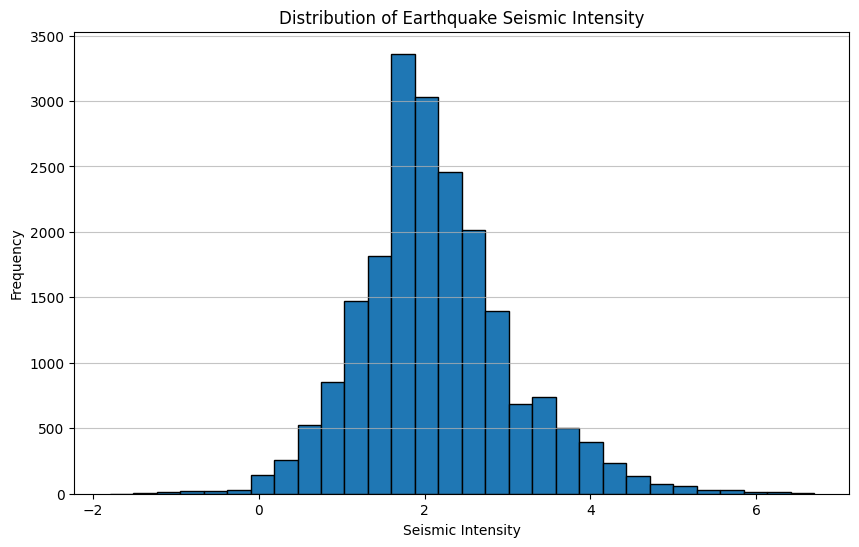

In [10]:
print("Number of earthquakes:", len(df))
print("\nColumns in the dataset:", df.columns.tolist())
print("\nMagnitude statistics:")
print(df['Seismic_Intensity'].describe())
plt.figure(figsize=(10, 6))
plt.hist(df['Seismic_Intensity'], bins=30, edgecolor='black')
plt.title('Distribution of Earthquake Seismic Intensity')
plt.xlabel('Seismic Intensity')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

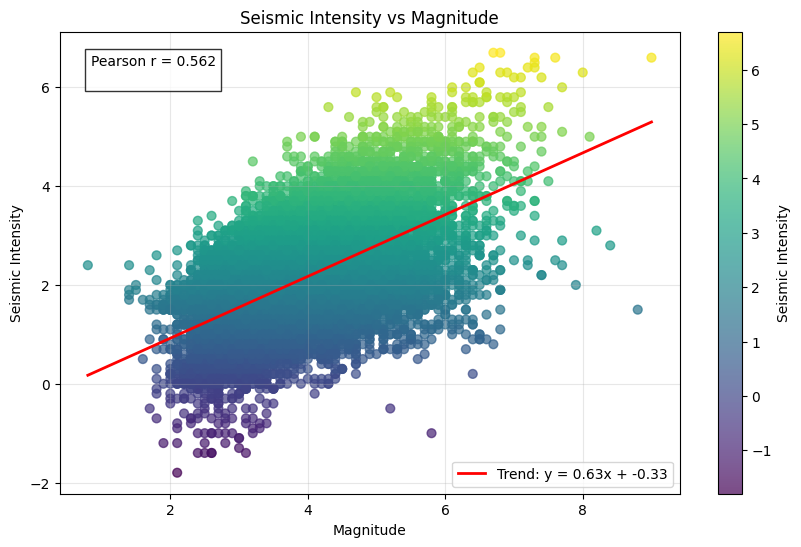

In [14]:
plot_df = df[['Magnitude', 'Seismic_Intensity']].dropna()
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    plot_df['Magnitude'],
    plot_df['Seismic_Intensity'],
    c=plot_df['Seismic_Intensity'],
    cmap='viridis',
    alpha=0.7,
    s=40
)

# Linear regression trend line
result = linregress(
    plot_df['Magnitude'],
    plot_df['Seismic_Intensity']
)

x = np.sort(plot_df['Magnitude'])

plt.plot(
    x,
    result.slope * x + result.intercept,
    color='red',
    linewidth=2,
    label=f'Trend: y = {result.slope:.2f}x + {result.intercept:.2f}'
)

# Correlation statistics
pearson_corr = plot_df['Magnitude'].corr(plot_df['Seismic_Intensity'])

# Display correlations on the figure
plt.text(
    0.05,
    0.95,
    f'Pearson r = {pearson_corr:.3f}\n',
    transform=plt.gca().transAxes,
    verticalalignment='top',
    bbox=dict(facecolor='white', alpha=0.8)
)

plt.title('Seismic Intensity vs Magnitude')
plt.xlabel('Magnitude')
plt.ylabel('Seismic Intensity')
plt.grid(alpha=0.3)
plt.legend()
plt.colorbar(scatter, label='Seismic Intensity')
plt.show()


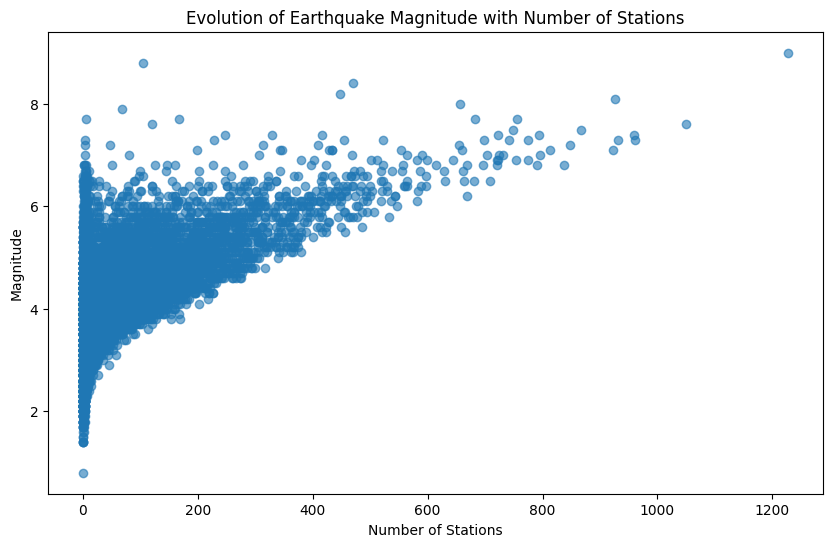

In [ ]:
# Make plt that show the evolution of the eathquake magnitude over the increase of nb of stations: the [Num_Stations] feature
plt.figure(figsize=(10, 6))
plt.scatter(df['Num_Stations'], df['Seismic_Intensity'], alpha=0.6)
plt.xlabel('Number of Stations')
plt.ylabel('Seismic Intensity')
plt.title('Evolution of Seismic Intensity with Number of Stations')
plt.show()

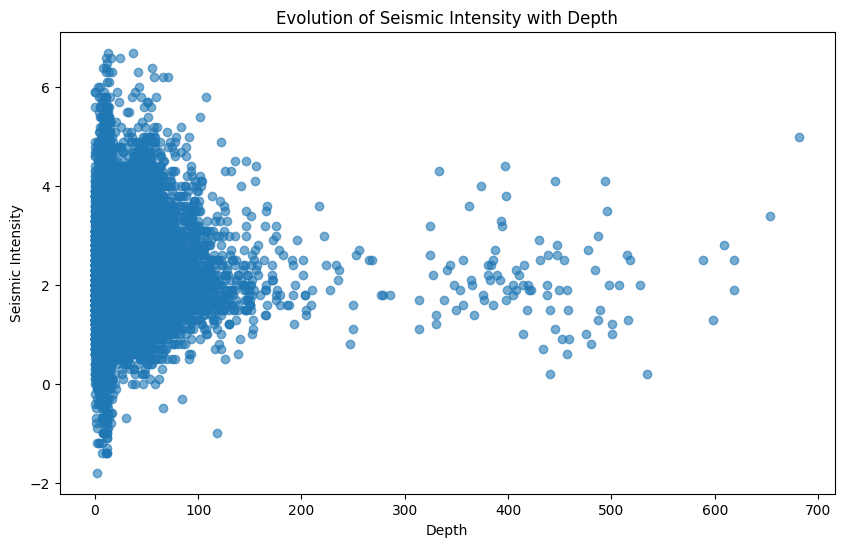

In [16]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Depth'], df['Seismic_Intensity'], alpha=0.6)
plt.xlabel('Depth')
plt.ylabel('Seismic Intensity')
plt.title('Evolution of Seismic Intensity with Depth')
plt.show()